# Fulton County Reading Lift Pilot: Hybrid Recommendation Demo

This notebook implements the recommendation system proposed for the middle-school pilot as a presentable, local-only demo.

- Synthetic catalog, student, and checkout data for a pilot cohort
- Collaborative filtering based on shared borrowing behavior
- Content-based similarity for sparse-history and cold-start students
- Grade-band policy guardrails and simple recommendation explanations

The notebook deliberately avoids an API or app shell so it can be demoed directly in Jupyter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

## 1. Build a synthetic pilot dataset

The proposal calls for a middle-school pilot with multiple schools, dense-history students, sparse-history students, and enough metadata to demonstrate both behavioral and content-based recommendations.

### Catalog

In [2]:
book_seed = [
    ('B001', 'Scythe', 'Neal Shusterman', 'Dystopian', 'ethics mortality future society', 'Arc of a Scythe', 'dystopian', 7, 8, 'A thoughtful dystopian story about power, mortality, and who gets to decide what is fair.'),
    ('B002', 'The Giver', 'Lois Lowry', 'Dystopian', 'memory control identity community', 'Standalone', 'dystopian', 6, 8, 'A quiet speculative novel about memory, conformity, and what it means to make human choices.'),
    ('B003', 'Legend', 'Marie Lu', 'Dystopian', 'rebellion survival government', 'Legend', 'dystopian', 7, 8, 'Fast-moving dystopian adventure centered on rebellion, loyalty, and survival.'),
    ('B004', 'Among the Hidden', 'Margaret Peterson Haddix', 'Dystopian', 'rules family secrecy courage', 'Shadow Children', 'dystopian', 6, 7, 'A middle-grade dystopian novel about hidden lives, risk, and courage.'),
    ('B005', 'The Maze Runner', 'James Dashner', 'Dystopian', 'mystery survival teamwork', 'Maze Runner', 'dystopian', 7, 8, 'A high-stakes survival story with puzzles, danger, and a tightly controlled environment.'),
    ('B006', 'Cinder', 'Marissa Meyer', 'Fantasy', 'identity technology fairytale resilience', 'The Lunar Chronicles', 'fantasy', 6, 8, 'A sci-fi fairy-tale retelling with invention, identity, and rebellion.'),
    ('B007', 'Amari and the Night Brothers', 'B. B. Alston', 'Fantasy', 'magic mystery bravery school', 'Supernatural Investigations', 'fantasy', 6, 7, 'A magical mystery with hidden worlds, school-style challenges, and brave choices.'),
    ('B008', 'Tristan Strong Punches a Hole in the Sky', 'Kwame Mbalia', 'Fantasy', 'myth adventure grief humor', 'Tristan Strong', 'fantasy', 6, 8, 'A myth-rich adventure that blends humor, bravery, and emotional depth.'),
    ('B009', 'The Last Cuentista', 'Donna Barba Higuera', 'Fantasy', 'storytelling future memory family', 'Standalone', 'fantasy', 6, 8, 'A lyrical speculative story about storytelling, family, and preserving cultural memory.'),
    ('B010', 'Aru Shah and the End of Time', 'Roshani Chokshi', 'Fantasy', 'myth friendship quests humor', 'Pandava', 'fantasy', 6, 7, 'A fast, funny fantasy quest rooted in mythology and friendship.'),
    ('B011', 'One of Us Is Lying', 'Karen M. McManus', 'Mystery', 'secrets school suspense perspective', 'Standalone', 'mystery', 8, 9, 'A suspenseful school mystery told through shifting perspectives and hidden motives.'),
    ('B012', 'The Parker Inheritance', 'Varian Johnson', 'Mystery', 'puzzle history friendship community', 'Standalone', 'mystery', 6, 8, 'A layered puzzle mystery with codes, family history, and determined problem-solving.'),
    ('B013', 'Escape from Mr. Lemoncellos Library', 'Chris Grabenstein', 'Mystery', 'games puzzles library teamwork', 'Mr. Lemoncello', 'mystery', 5, 7, 'A library puzzle adventure built around clues, teamwork, and playful competition.'),
    ('B014', 'Greenglass House', 'Kate Milford', 'Mystery', 'winter secrets smuggling setting', 'Greenglass House', 'mystery', 6, 8, 'An atmospheric mystery full of secrets, storytelling, and careful observation.'),
    ('B015', 'The Westing Game', 'Ellen Raskin', 'Mystery', 'logic inheritance clues ensemble', 'Standalone', 'mystery', 6, 8, 'A classic puzzle mystery where every clue matters and every reader can play detective.'),
    ('B016', 'The Crossover', 'Kwame Alexander', 'Sports', 'basketball family rhythm identity', 'Crossover', 'sports', 6, 8, 'A verse novel about basketball, family, and finding your own voice.'),
    ('B017', 'Ghost', 'Jason Reynolds', 'Sports', 'running friendship growth resilience', 'Track', 'sports', 6, 8, 'A sharp, fast-paced sports story about running, friendship, and personal growth.'),
    ('B018', 'Front Desk', 'Kelly Yang', 'Realistic', 'family work fairness courage', 'Front Desk', 'realistic', 6, 8, 'A realistic story about family responsibility, fairness, and speaking up.'),
    ('B019', 'New Kid', 'Jerry Craft', 'Graphic Novel', 'belonging school friendship humor', 'New Kid', 'graphic', 6, 8, 'A graphic novel about belonging, identity, school culture, and friendship.'),
    ('B020', 'Class Act', 'Jerry Craft', 'Graphic Novel', 'school humor friendship perspective', 'New Kid', 'graphic', 6, 8, 'A character-driven graphic novel about social perspective, humor, and school life.'),
    ('B021', 'Invisible', 'Christina Diaz Gonzalez', 'Graphic Novel', 'community teamwork language empathy', 'Standalone', 'graphic', 6, 8, 'A graphic novel about empathy, teamwork, and how students build community together.'),
    ('B022', 'Hidden Figures Young Readers Edition', 'Margot Lee Shetterly', 'STEM', 'science perseverance history role models', 'Standalone', 'stem', 6, 8, 'A nonfiction STEM story about perseverance, math, and overlooked pioneers.'),
    ('B023', 'The Last Kids on Earth', 'Max Brallier', 'Adventure', 'humor monsters friendship survival', 'The Last Kids on Earth', 'adventure', 5, 7, 'A high-energy illustrated adventure with humor, monsters, and survival teamwork.'),
    ('B024', 'Enders Game', 'Orson Scott Card', 'Science Fiction', 'strategy war leadership pressure', 'Ender', 'science_fiction', 8, 10, 'A strategic science fiction novel about leadership, pressure, and ethical decision-making.'),
    ('B025', 'The Wild Robot', 'Peter Brown', 'Adventure', 'nature robotics kindness survival', 'The Wild Robot', 'adventure', 5, 6, 'A reflective survival story about kindness, adaptation, and belonging.'),
    ('B026', 'Brown Girl Dreaming', 'Jacqueline Woodson', 'Realistic', 'voice memoir family poetry', 'Standalone', 'realistic', 6, 8, 'A memoir in verse about voice, family, memory, and growing into yourself.')
]

catalog = pd.DataFrame(
    book_seed,
    columns=['book_id', 'title', 'author', 'genre', 'theme', 'series', 'cluster', 'min_grade', 'max_grade', 'description']
)
catalog['content_text'] = catalog['genre'] + ' ' + catalog['theme'] + ' ' + catalog['series'] + ' ' + catalog['description']
catalog.head(3)

,book_id,title,author,genre,theme,series,cluster,min_grade,max_grade,description,content_text
0,B001,Scythe,Neal Shusterman,Dystopian,ethics mortality future society,Arc of a Scythe,dystopian,7,8,"A thoughtful dystopian story about power, mortality, and who gets to decide what is fair.","Dystopian ethics mortality future society Arc of a Scythe A thoughtful dystopian story about power, mortality, and w..."
1,B002,The Giver,Lois Lowry,Dystopian,memory control identity community,Standalone,dystopian,6,8,"A quiet speculative novel about memory, conformity, and what it means to make human choices.","Dystopian memory control identity community Standalone A quiet speculative novel about memory, conformity, and what ..."
2,B003,Legend,Marie Lu,Dystopian,rebellion survival government,Legend,dystopian,7,8,"Fast-moving dystopian adventure centered on rebellion, loyalty, and survival.","Dystopian rebellion survival government Legend Fast-moving dystopian adventure centered on rebellion, loyalty, and s..."


### Students

In [3]:

student_seed = [
    ('S001', 'Maya Brooks', 'Bear Creek MS', 6, 'Fantasy explorer who likes myths, friendship, and school mysteries', 'fantasy', 'dense'),
    ('S002', 'Jordan Ellis', 'Bear Creek MS', 6, 'Graphic novel reader drawn to humor, belonging, and friendship', 'graphic', 'moderate'),
    ('S003', 'Avery Patel', 'Bear Creek MS', 6, 'Puzzle-loving mystery reader who enjoys library games and clues', 'mystery', 'dense'),
    ('S004', 'Noah Rivera', 'Bear Creek MS', 7, 'Dystopian reader interested in survival, rebellion, and hard choices', 'dystopian', 'dense'),
    ('S005', 'Layla Nguyen', 'Bear Creek MS', 7, 'Sports and realistic fiction reader who likes family and grit', 'sports', 'moderate'),
    ('S006', 'Ethan Cooper', 'Bear Creek MS', 8, 'Science-minded reader interested in strategy, technology, and pressure', 'science_fiction', 'sparse'),
    ('S007', 'Zoe Jackson', 'Northgate MS', 6, 'Fantasy reader who likes humor, quests, and brave heroines', 'fantasy', 'dense'),
    ('S008', 'Daniel Kim', 'Northgate MS', 6, 'STEM-curious reader interested in science, history, and perseverance', 'stem', 'cold_start'),
    ('S009', 'Amina Hassan', 'Northgate MS', 7, 'Graphic novel reader who responds to identity, empathy, and school stories', 'graphic', 'moderate'),
    ('S010', 'Lucas Reed', 'Northgate MS', 7, 'Dystopian reader who likes fast-paced survival stories and team strategy', 'dystopian', 'dense'),
    ('S011', 'Sophia Turner', 'Northgate MS', 8, 'Mystery reader who likes layered puzzles and hidden motives', 'mystery', 'dense'),
    ('S012', 'Caleb Martin', 'Northgate MS', 8, 'Realistic fiction reader drawn to family, fairness, and voice', 'realistic', 'sparse'),
    ('S013', 'Emma Diaz', 'Webb Bridge MS', 6, 'Adventure reader who likes humor, monsters, and teamwork', 'adventure', 'moderate'),
    ('S014', 'Elijah Green', 'Webb Bridge MS', 6, 'Mystery reader who likes codes, teamwork, and quick puzzle wins', 'mystery', 'sparse'),
    ('S015', 'Harper Lewis', 'Webb Bridge MS', 7, 'Sports and verse reader who likes basketball, rhythm, and family stakes', 'sports', 'dense'),
    ('S016', 'Mason Clark', 'Webb Bridge MS', 7, 'Dystopian and science fiction reader who likes control systems and strategy', 'dystopian', 'moderate'),
    ('S017', 'Chloe Adams', 'Webb Bridge MS', 8, 'Fantasy and speculative reader interested in memory, identity, and storytelling', 'fantasy', 'dense'),
    ('S018', 'Benjamin Scott', 'Webb Bridge MS', 8, 'New-to-reading-profile student with interest in basketball and graphic novels', 'sports', 'cold_start')
]

students = pd.DataFrame(
    student_seed,
    columns=['student_id', 'student_name', 'school', 'grade', 'interest_text', 'interest_cluster', 'history_segment']
)

students.head(3)

,student_id,student_name,school,grade,interest_text,interest_cluster,history_segment
0,S001,Maya Brooks,Bear Creek MS,6,"Fantasy explorer who likes myths, friendship, and school mysteries",fantasy,dense
1,S002,Jordan Ellis,Bear Creek MS,6,"Graphic novel reader drawn to humor, belonging, and friendship",graphic,moderate
2,S003,Avery Patel,Bear Creek MS,6,Puzzle-loving mystery reader who enjoys library games and clues,mystery,dense


### Tag Clusters

In [4]:
adjacent_clusters = {
    'dystopian': ['science_fiction', 'mystery'],
    'fantasy': ['adventure', 'graphic'],
    'mystery': ['graphic', 'dystopian'],
    'sports': ['realistic', 'graphic'],
    'graphic': ['realistic', 'mystery'],
    'stem': ['science_fiction', 'realistic'],
    'realistic': ['sports', 'graphic'],
    'adventure': ['fantasy', 'graphic'],
    'science_fiction': ['dystopian', 'stem'],
}

books_by_cluster = {cluster: group['book_id'].tolist() for cluster, group in catalog.groupby('cluster')}
history_counts = {'dense': 6, 'moderate': 4, 'sparse': 2, 'cold_start': 0}
checkout_rows = []

books_by_cluster

{'adventure': ['B023', 'B025'],
 'dystopian': ['B001', 'B002', 'B003', 'B004', 'B005'],
 'fantasy': ['B006', 'B007', 'B008', 'B009', 'B010'],
 'graphic': ['B019', 'B020', 'B021'],
 'mystery': ['B011', 'B012', 'B013', 'B014', 'B015'],
 'realistic': ['B018', 'B026'],
 'science_fiction': ['B024'],
 'sports': ['B016', 'B017'],
 'stem': ['B022']}

### Checkouts

In [5]:
for student in students.itertuples(index=False):
    n_books = history_counts[student.history_segment]
    if n_books == 0:
        continue

    primary_ids = books_by_cluster.get(student.interest_cluster, [])
    adjacent_ids = []
    for cluster in adjacent_clusters.get(student.interest_cluster, []):
        adjacent_ids.extend(books_by_cluster.get(cluster, []))

    primary_take = min(max(n_books - 1, 1), len(primary_ids))
    chosen_primary = list(rng.choice(primary_ids, size=primary_take, replace=False)) if primary_ids else []
    remaining = n_books - len(chosen_primary)

    chosen_adjacent = []
    if remaining > 0 and adjacent_ids:
        chosen_adjacent = list(rng.choice(adjacent_ids, size=min(remaining, len(adjacent_ids)), replace=False))

    chosen_books = chosen_primary + chosen_adjacent

    for offset, book_id in enumerate(chosen_books):
        checkout_rows.append({
            'student_id': student.student_id,
            'book_id': book_id,
            'checkout_date': pd.Timestamp('2026-01-15') + pd.Timedelta(days=int(rng.integers(0, 45)) + offset),
        })
        
checkouts = pd.DataFrame(checkout_rows).sort_values('checkout_date').reset_index(drop=True)
checkouts.head()

,student_id,book_id,checkout_date
0,S015,B017,2026-01-16
1,S011,B013,2026-01-18
2,S001,B010,2026-01-19
3,S009,B019,2026-01-19
4,S010,B005,2026-01-19


### Seed Summary

In [6]:
pd.DataFrame(
    {
        'metric': ['catalog_titles', 'students', 'checkout_events', 'cold_start_students'],
        'value': [len(catalog), len(students), len(checkouts), int((students['history_segment'] == 'cold_start').sum())],
    }
)

,metric,value
0,catalog_titles,26
1,students,18
2,checkout_events,74
3,cold_start_students,2


## 2. Prepare the hybrid recommendation features

The proposal recommends a hybrid stack: collaborative filtering as the main behavioral signal, content similarity for cold start and discovery, and policy guardrails before anything is shown.

### How Collaborative Filtering works

**Collaborative Filtering (CF)** recommends books based on shared borrowing behaviour across students — "students like you also checked out...".

**Step 1 — Build an interactions matrix.**  
Each row is a student, each column is a book, and each cell is 1 if the student borrowed that book (0 otherwise).

**Step 2 — Compute student-to-student cosine similarity.**  
Two students are similar if they checked out many of the same books. Cosine similarity measures the angle between their borrowing vectors: 1.0 = identical reading patterns, 0.0 = no overlap.

$$\text{similarity}(A, B) = \frac{\vec{A} \cdot \vec{B}}{\|\vec{A}\| \|\vec{B}\|}$$

**Step 3 — Score every unread book.**  
For each book, sum its borrow-counts across all neighbours, weighted by how similar each neighbour is. Neighbours with stronger overlap contribute more.

$$\text{cf\_score}(u, b) = \frac{\sum_{v \in N} \text{sim}(u,v) \cdot \text{interactions}(v,b)}{\sum_{v \in N} \text{sim}(u,v)}$$

For students with little or no checkout history the neighbour set is empty and CF scores collapse to zero — which is why content similarity takes over as the primary signal.

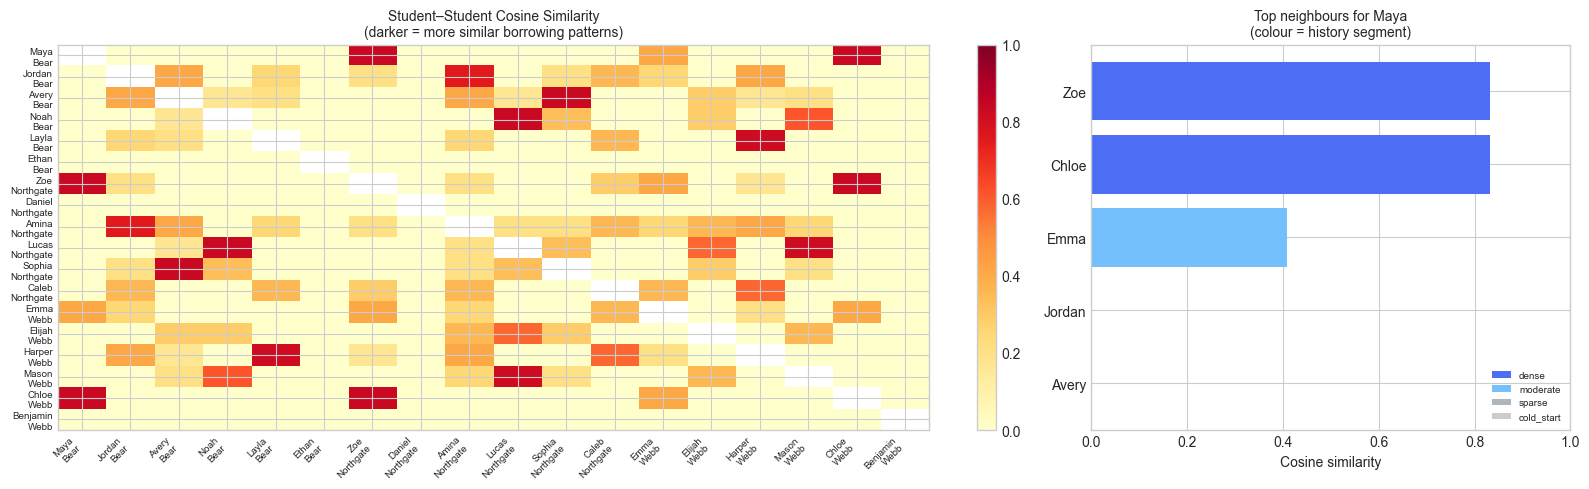

In [18]:
# --- CF visualisation: student-student similarity heatmap ---
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Build interactions and similarity here so the cell is self-contained
# (they are rebuilt in later cells; this just shows the intuition)
_interactions = (
    checkouts.assign(value=1)
    .pivot_table(index='student_id', columns='book_id', values='value', aggfunc='sum', fill_value=0)
    .reindex(index=students['student_id'], columns=catalog['book_id'], fill_value=0)
)
from sklearn.metrics.pairwise import cosine_similarity as _cos
_sim = _cos(_interactions.values)
np.fill_diagonal(_sim, np.nan)  # hide self-similarity for clarity

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 1]})

# Left: similarity heatmap
labels = students['student_name'].str.split().str[0] + '\n' + students['school'].str.split().str[0]
im = axes[0].imshow(_sim, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels, fontsize=7)
axes[0].set_title('Student–Student Cosine Similarity\n(darker = more similar borrowing patterns)', fontsize=10)
plt.colorbar(im, ax=axes[0], fraction=0.04)

# Right: top-5 neighbours for Maya Brooks (S001, dense-history fantasy reader)
target = 'S001'
target_name = students.set_index('student_id').loc[target, 'student_name'].split()[0]
sim_series = _cos(_interactions.loc[[target]].values, _interactions.values).ravel()
sim_df = students[['student_id', 'student_name', 'history_segment']].copy()
sim_df['similarity'] = sim_series
sim_df = sim_df[sim_df['student_id'] != target].nlargest(5, 'similarity')

colors = {'dense': '#4C6EF5', 'moderate': '#74C0FC', 'sparse': '#ADB5BD', 'cold_start': '#CCC'}
bar_colors = [colors.get(s, '#999') for s in sim_df['history_segment']]
axes[1].barh(sim_df['student_name'].str.split().str[0], sim_df['similarity'], color=bar_colors)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Cosine similarity')
axes[1].set_title(f'Top neighbours for {target_name}\n(colour = history segment)', fontsize=10)
axes[1].invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
axes[1].legend(handles=legend_elements, fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

### How TF-IDF content similarity works

**TF-IDF (Term Frequency–Inverse Document Frequency)** turns text into a numeric vector where words that are *distinctive* to a particular book are given high weight, and words that appear across all books are down-weighted.

$$\text{tfidf}(t, d) = \underbrace{\frac{\text{count}(t,d)}{\text{total terms in } d}}_{\text{TF}} \times \underbrace{\log\frac{N}{\text{docs containing } t}}_{\text{IDF}}$$

Each book's `content_text` (genre + theme + series + description) is vectorized this way, producing a sparse matrix where every column is a vocabulary word.

**Student vectors** are built the same way:  
- If a student has checkout history → average the TF-IDF vectors of their checked-out books (75%) blended with their interest description vector (25%)  
- If cold-start → use only the interest description vector (100%)

**Scoring** is then a single cosine similarity call between the student vector and all 26 book vectors. Books whose text most closely matches the student's reading profile score highest.

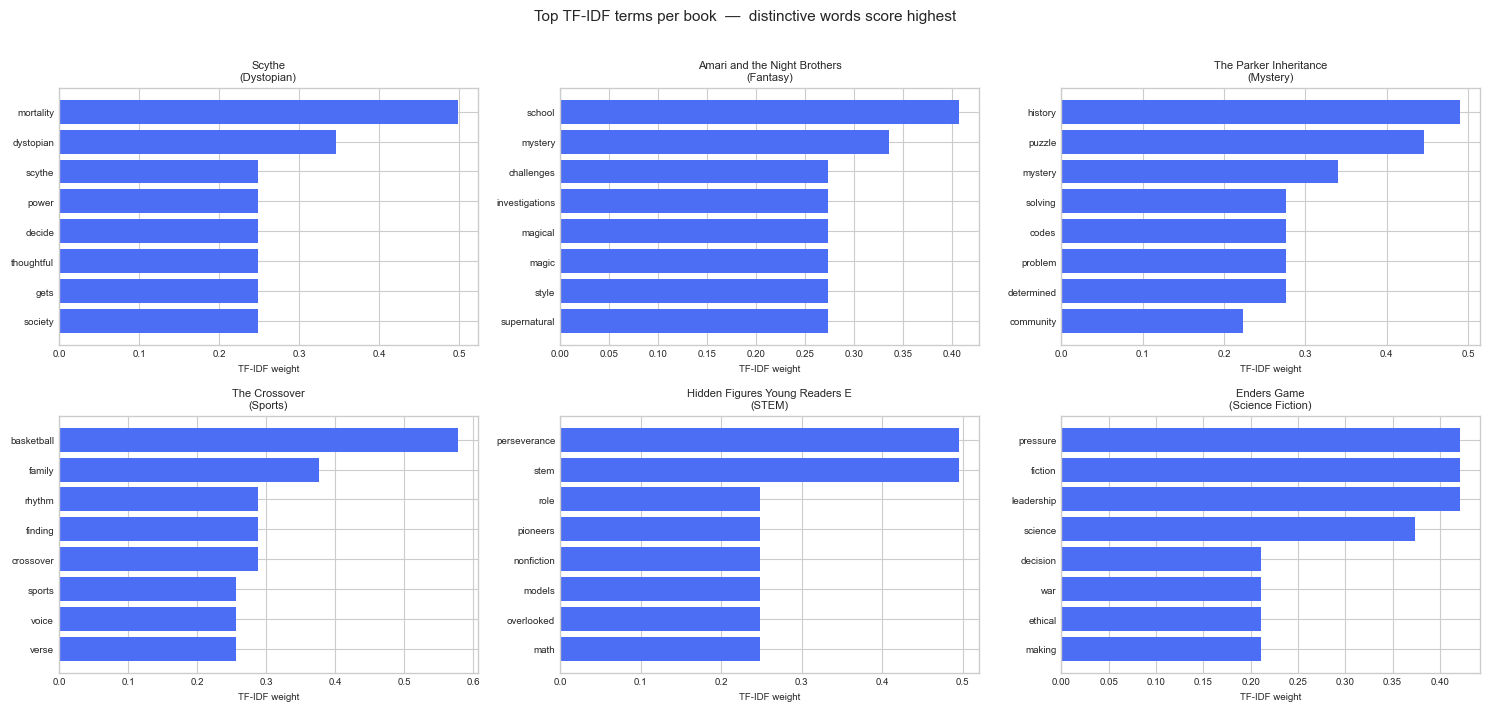

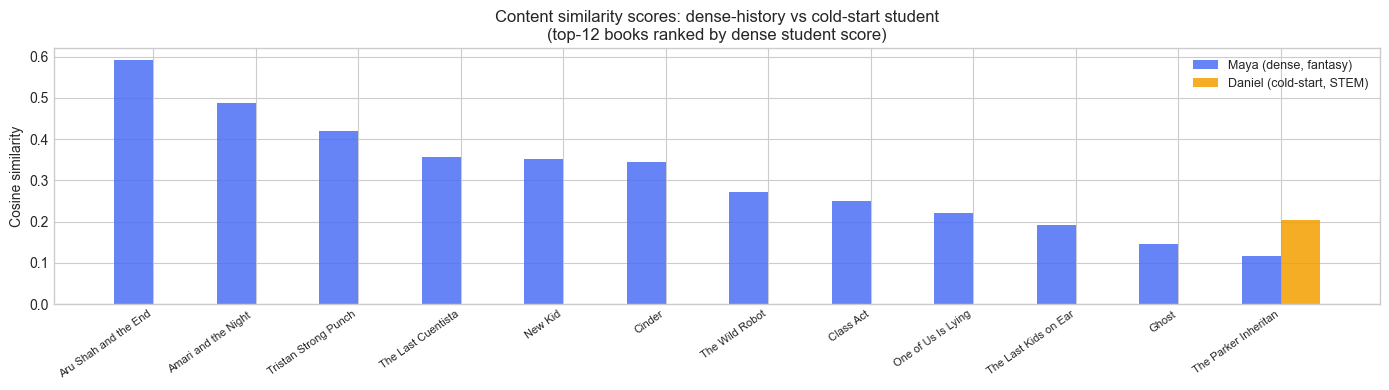

In [19]:
# --- TF-IDF visualisation ---
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

_vec = TfidfVectorizer(stop_words='english', max_features=200)
_book_tfidf = _vec.fit_transform(catalog['content_text'])
_terms = np.array(_vec.get_feature_names_out())

# --- Panel 1: top-8 TF-IDF terms for 6 sampled books ---
sample_ids = ['B001', 'B007', 'B012', 'B016', 'B022', 'B024']
sample_books = catalog.set_index('book_id').loc[sample_ids]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (book_id, book_row) in zip(axes.ravel(), sample_books.iterrows()):
    row_idx = catalog.index[catalog['book_id'] == book_id][0]
    weights = _book_tfidf[row_idx].toarray().ravel()
    top_idx = np.argsort(weights)[-8:][::-1]
    ax.barh(_terms[top_idx][::-1], weights[top_idx][::-1], color='#4C6EF5')
    ax.set_title(f"{book_row['title'][:30]}\n({book_row['genre']})", fontsize=8)
    ax.set_xlabel('TF-IDF weight', fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=7)

fig.suptitle('Top TF-IDF terms per book  —  distinctive words score highest', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# --- Panel 2: content score comparison — cold-start vs dense student ---
_student_vecs = {}
for student in students.itertuples(index=False):
    h_ids = checkouts.loc[checkouts['student_id'] == student.student_id, 'book_id'].tolist()
    h_rows = [catalog.index[catalog['book_id'] == b][0] for b in h_ids]
    iv = _vec.transform([student.interest_text]).toarray()
    if h_rows:
        hv = np.asarray(_book_tfidf[h_rows].mean(axis=0))
        _student_vecs[student.student_id] = hv * 0.75 + iv * 0.25
    else:
        _student_vecs[student.student_id] = iv

from sklearn.metrics.pairwise import cosine_similarity as _cos2

dense_id   = students.loc[students['history_segment'] == 'dense',      'student_id'].iloc[0]
cold_id    = students.loc[students['history_segment'] == 'cold_start',  'student_id'].iloc[0]
dense_name = students.set_index('student_id').loc[dense_id,  'student_name'].split()[0]
cold_name  = students.set_index('student_id').loc[cold_id,   'student_name'].split()[0]

dense_scores = _cos2(_student_vecs[dense_id], _book_tfidf).ravel()
cold_scores  = _cos2(_student_vecs[cold_id],  _book_tfidf).ravel()

score_df = catalog[['book_id', 'title', 'cluster']].copy()
score_df['dense'] = dense_scores
score_df['cold']  = cold_scores
score_df = score_df.sort_values('dense', ascending=False).head(12)

x = np.arange(len(score_df))
width = 0.38
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x - width/2, score_df['dense'], width, label=f'{dense_name} (dense, fantasy)', color='#4C6EF5', alpha=0.85)
ax.bar(x + width/2, score_df['cold'],  width, label=f'{cold_name} (cold-start, STEM)', color='#F59F00', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(score_df['title'].str[:20], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Cosine similarity')
ax.set_title('Content similarity scores: dense-history vs cold-start student\n(top-12 books ranked by dense student score)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Checkouts Interactions Table

In [7]:
interactions = (
    checkouts.assign(value=1)
    .pivot_table(index='student_id', columns='book_id', values='value', aggfunc='sum', fill_value=0)
    .reindex(index=students['student_id'], columns=catalog['book_id'], fill_value=0)
)

interactions

book_id,B001,B002,B003,B004,B005,B006,B007,B008,B009,B010,...,B017,B018,B019,B020,B021,B022,B023,B024,B025,B026
student_id,,,,,,,,,,,,,,,,,,,,,
S001,0,0,0,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,0
S002,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,0
S003,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
S004,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S005,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
S006,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
S007,0,0,0,0,0,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0
S008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S009,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,0


### Student Interactions Cosine Similarirty Matrix

In [8]:
student_similarity = pd.DataFrame(
    cosine_similarity(interactions.values),
    index=interactions.index,
    columns=interactions.index,
)
np.fill_diagonal(student_similarity.values, 0.0)
student_similarity

student_id,S001,S002,S003,S004,S005,S006,S007,S008,S009,S010,S011,S012,S013,S014,S015,S016,S017,S018
student_id,,,,,,,,,,,,,,,,,,
S001,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.833333,0.0,0.000000,0.000000,0.000000,0.000000,0.408248,0.000000,0.000000,0.000000,0.833333,0.0
S002,0.000000,0.000000,0.408248,0.000000,0.250000,0.0,0.204124,0.0,0.750000,0.000000,0.204124,0.353553,0.250000,0.000000,0.408248,0.000000,0.000000,0.0
S003,0.000000,0.408248,0.000000,0.166667,0.204124,0.0,0.000000,0.0,0.408248,0.166667,0.833333,0.000000,0.000000,0.288675,0.166667,0.204124,0.000000,0.0
S004,0.000000,0.000000,0.166667,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.833333,0.333333,0.000000,0.000000,0.288675,0.000000,0.612372,0.000000,0.0
S005,0.000000,0.250000,0.204124,0.000000,0.000000,0.0,0.000000,0.0,0.250000,0.000000,0.000000,0.353553,0.000000,0.000000,0.816497,0.000000,0.000000,0.0
S006,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
S007,0.833333,0.204124,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.204124,0.000000,0.000000,0.288675,0.408248,0.000000,0.166667,0.000000,0.833333,0.0
S008,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
S009,0.000000,0.750000,0.408248,0.000000,0.250000,0.0,0.204124,0.0,0.000000,0.204124,0.204124,0.353553,0.250000,0.353553,0.408248,0.250000,0.000000,0.0


### Capture Student Content Vector
Combines TF-IDF over reading history and cold-start described interest into a single vector

In [11]:
vectorizer = TfidfVectorizer(stop_words='english')
book_tfidf = vectorizer.fit_transform(catalog['content_text'])
book_id_to_row = {book_id: idx for idx, book_id in enumerate(catalog['book_id'])}

student_content_vectors = {}
for student in students.itertuples(index=False):
    history_ids = checkouts.loc[checkouts['student_id'] == student.student_id, 'book_id'].tolist()
    history_rows = [book_id_to_row[book_id] for book_id in history_ids]
    interest_vector = vectorizer.transform([student.interest_text]).toarray()

    if history_rows:
        history_vector = np.asarray(book_tfidf[history_rows].mean(axis=0))
        student_vector = history_vector * 0.75 + interest_vector * 0.25
    else:
        student_vector = interest_vector

    student_content_vectors[student.student_id] = student_vector

### Popularity by Grade

In [13]:
school_grade_popularity = (
    checkouts
    .merge(students[['student_id', 'school', 'grade']], on='student_id', how='left')
    .groupby(['school', 'grade', 'book_id'])
    .size()
    .rename('borrow_count')
    .reset_index()
)
school_grade_popularity.sort_values(['school', 'grade', 'borrow_count'], ascending=[True, True, False]).head(10)

,school,grade,book_id,borrow_count
6,Bear Creek MS,6,B012,2
10,Bear Creek MS,6,B019,2
0,Bear Creek MS,6,B006,1
1,Bear Creek MS,6,B007,1
2,Bear Creek MS,6,B008,1
3,Bear Creek MS,6,B009,1
4,Bear Creek MS,6,B010,1
5,Bear Creek MS,6,B011,1
7,Bear Creek MS,6,B013,1
8,Bear Creek MS,6,B014,1


### Recommendation Utility Functions
`normalize_scores(series)`

Min-max scales any score series to [0, 1] so that CF, content, and popularity scores are on the same scale before being blended. Returns all zeros if every value is identical.

`borrowing_history(student_id)`

Returns a student's past checkouts as a tidy DataFrame (date, title, author, cluster), ordered newest-first. Used by build_explanation to find titles to reference in the explanation text.

`collaborative_scores(student_id)`

Weighted-average of what similar students checked out — neighbors are weighted by their cosine similarity to the target student. Returns all zeros if the student shares no checkout overlap with anyone.

`content_scores(student_id)`

Computes cosine similarity between the student's pre-built content vector (from cell 19) and every book's TF-IDF vector. Higher score = more textually similar to what the student has read or described as their interest.

`popularity_scores(student_id)`

Looks up raw borrow counts at the same school and grade level. Books not borrowed by that cohort get a count of 0. This is the fallback signal that ensures something sensible comes back even with zero behavior and weak content overlap.

`weighting_profile(student_id)`

The router: counts how many books a student has checked out and returns the appropriate CF/content/popularity weight mix — behavior-led (≥5 books), balanced (2–4), or cold-start (0–1).

`guardrail_reason(student_grade, book_min, book_max)`

Single-purpose policy check: returns a human-readable block reason if the student's grade falls outside a book's allowed grade band, otherwise None. A non-None return excludes the book from recommendations entirely.

In [15]:
def normalize_scores(series: pd.Series) -> pd.Series:
    series = series.astype(float).fillna(0.0)
    max_value = float(series.max())
    min_value = float(series.min())
    if max_value == min_value:
        return pd.Series(0.0, index=series.index)
    return (series - min_value) / (max_value - min_value)


def borrowing_history(student_id: str) -> pd.DataFrame:
    history = (
        checkouts.loc[checkouts['student_id'] == student_id]
        .merge(catalog[['book_id', 'title', 'author', 'cluster']], on='book_id', how='left')
        .sort_values('checkout_date', ascending=False)
    )
    return history[['checkout_date', 'title', 'author', 'cluster']].reset_index(drop=True)


def collaborative_scores(student_id: str) -> pd.Series:
    similarities = student_similarity.loc[student_id]
    positive_neighbors = similarities[similarities > 0]

    if positive_neighbors.empty:
        return pd.Series(0.0, index=interactions.columns)

    weighted_counts = interactions.loc[positive_neighbors.index].T.dot(positive_neighbors)
    return weighted_counts / positive_neighbors.sum()


def content_scores(student_id: str) -> pd.Series:
    student_vector = student_content_vectors[student_id]
    scores = cosine_similarity(student_vector, book_tfidf).ravel()
    return pd.Series(scores, index=catalog['book_id'])


def popularity_scores(student_id: str) -> pd.Series:
    student = students.set_index('student_id').loc[student_id]
    subset = school_grade_popularity[
        (school_grade_popularity['school'] == student['school'])
        & (school_grade_popularity['grade'] == student['grade'])
    ][['book_id', 'borrow_count']]

    merged = catalog[['book_id']].merge(subset, on='book_id', how='left').fillna({'borrow_count': 0})
    return pd.Series(merged['borrow_count'].to_numpy(), index=merged['book_id'])


def weighting_profile(student_id: str) -> dict:
    history_size = int(interactions.loc[student_id].sum())
    if history_size >= 5:
        return {'mode': 'behavior-led', 'cf': 0.55, 'content': 0.30, 'popularity': 0.15}
    if history_size >= 2:
        return {'mode': 'balanced', 'cf': 0.35, 'content': 0.45, 'popularity': 0.20}
    return {'mode': 'cold-start', 'cf': 0.10, 'content': 0.60, 'popularity': 0.30}


def guardrail_reason(student_grade: int, book_min: int, book_max: int) -> str | None:
    if student_grade < book_min:
        return f'Blocked: title starts at grade {book_min}'
    if student_grade > book_max:
        return f'Blocked: title caps at grade {book_max}'
    return None

## 3. Rank books with collaborative, content, popularity, and guardrail signals

The ranker keeps the proposal's priority order: behavior where possible, content when history is thin, and policy checks before a title can be returned.

In [16]:
def build_explanation(student_row: pd.Series, book_row: pd.Series, score_row: pd.Series) -> str:
    history = borrowing_history(student_row['student_id'])
    matched_titles = history.loc[history['cluster'] == book_row['cluster'], 'title'].head(2).tolist()

    dominant_signal = max(
        [('collaborative', score_row['cf_score']), ('content', score_row['content_score']), ('popularity', score_row['popularity_score'])],
        key=lambda item: item[1],
    )[0]

    if dominant_signal == 'collaborative' and matched_titles:
        title_list = ' and '.join(matched_titles[:2])
        return f"Students with borrowing patterns similar to {student_row['student_name']} also checked out this after titles like {title_list}."

    if dominant_signal == 'content':
        return f"This fits the student's interest profile around {book_row['genre'].lower()} reads and themes like {book_row['theme'].split()[0]}."

    return f"This is trending with grade {student_row['grade']} readers at {student_row['school']} and still fits the pilot guardrails."


def recommend_for(student_id: str, top_n: int = 5) -> tuple[pd.DataFrame, pd.DataFrame]:
    student_row = students.set_index('student_id').loc[student_id]
    student_view = student_row.copy()
    student_view['student_id'] = student_id
    weights = weighting_profile(student_id)

    cf = normalize_scores(collaborative_scores(student_id))
    content = normalize_scores(content_scores(student_id))
    popularity = normalize_scores(popularity_scores(student_id))

    scored = catalog.copy()
    scored['cf_score'] = scored['book_id'].map(cf)
    scored['content_score'] = scored['book_id'].map(content)
    scored['popularity_score'] = scored['book_id'].map(popularity)
    scored['hybrid_score'] = (
        scored['cf_score'] * weights['cf']
        + scored['content_score'] * weights['content']
        + scored['popularity_score'] * weights['popularity']
    )

    already_read = set(checkouts.loc[checkouts['student_id'] == student_id, 'book_id'])
    scored['already_read'] = scored['book_id'].isin(already_read)
    scored['guardrail'] = scored.apply(
        lambda row: guardrail_reason(int(student_row['grade']), int(row['min_grade']), int(row['max_grade'])),
        axis=1,
    )

    blocked = (
        scored.loc[(~scored['already_read']) & scored['guardrail'].notna()]
        .sort_values('hybrid_score', ascending=False)
        [['title', 'author', 'genre', 'min_grade', 'max_grade', 'hybrid_score', 'guardrail']]
        .head(5)
        .reset_index(drop=True)
    )

    recommendations = (
        scored.loc[(~scored['already_read']) & scored['guardrail'].isna()]
        .sort_values('hybrid_score', ascending=False)
        .head(top_n)
        .copy()
    )

    recommendations['rank'] = range(1, len(recommendations) + 1)
    recommendations['mode'] = weights['mode']
    recommendations['explanation'] = recommendations.apply(
        lambda row: build_explanation(student_view, row, row),
        axis=1,
    )

    recommendation_view = recommendations[[
        'rank', 'title', 'author', 'genre', 'series', 'hybrid_score', 'cf_score', 'content_score', 'popularity_score', 'mode', 'explanation'
    ]].reset_index(drop=True)

    return recommendation_view.round({'hybrid_score': 3, 'cf_score': 3, 'content_score': 3, 'popularity_score': 3}), blocked.round({'hybrid_score': 3})


dense_student_id = students.loc[students['history_segment'] == 'dense', 'student_id'].iloc[0]
cold_start_student_id = students.loc[students['history_segment'] == 'cold_start', 'student_id'].iloc[0]

students.loc[
    students['student_id'].isin([dense_student_id, cold_start_student_id]),
    ['student_id', 'student_name', 'school', 'grade', 'history_segment', 'interest_text'],
]

,student_id,student_name,school,grade,history_segment,interest_text
0,S001,Maya Brooks,Bear Creek MS,6,dense,"Fantasy explorer who likes myths, friendship, and school mysteries"
7,S008,Daniel Kim,Northgate MS,6,cold_start,"STEM-curious reader interested in science, history, and perseverance"


## 4. Demo a dense-history student

This case shows the behavioral path the proposal wants as the primary signal: collaborative filtering contributes strongly because the student has enough borrowing history.

In [17]:
dense_student = students.set_index('student_id').loc[dense_student_id]
dense_recommendations, dense_blocked = recommend_for(dense_student_id)

print(f"Dense-history demo: {dense_student['student_name']} ({dense_student['school']}, grade {dense_student['grade']})")
print(f"Weighting mode: {weighting_profile(dense_student_id)['mode']}")
print('')
print('Recent borrowing history')
display(borrowing_history(dense_student_id))
print('Top recommendations')
display(dense_recommendations)
print('Top blocked candidates after guardrails')
display(dense_blocked)

Dense-history demo: Maya Brooks (Bear Creek MS, grade 6)
Weighting mode: behavior-led

Recent borrowing history


,checkout_date,title,author,cluster
0,2026-03-01,Cinder,Marissa Meyer,fantasy
1,2026-02-22,Tristan Strong Punches a Hole in the Sky,Kwame Mbalia,fantasy
2,2026-02-21,The Wild Robot,Peter Brown,adventure
3,2026-02-20,The Last Cuentista,Donna Barba Higuera,fantasy
4,2026-02-08,Amari and the Night Brothers,B. B. Alston,fantasy
5,2026-01-19,Aru Shah and the End of Time,Roshani Chokshi,fantasy


Top recommendations


,rank,title,author,genre,series,hybrid_score,cf_score,content_score,popularity_score,mode,explanation
0,1,Class Act,Jerry Craft,Graphic Novel,New Kid,0.530,0.598,0.419,0.5,behavior-led,This is trending with grade 6 readers at Bear Creek MS and still fits the pilot guardrails.
1,2,The Last Kids on Earth,Max Brallier,Adventure,The Last Kids on Earth,0.427,0.598,0.326,0.0,behavior-led,Students with borrowing patterns similar to Maya Brooks also checked out this after titles like The Wild Robot.
2,3,New Kid,Jerry Craft,Graphic Novel,New Kid,0.328,0.000,0.595,1.0,behavior-led,This is trending with grade 6 readers at Bear Creek MS and still fits the pilot guardrails.
3,4,The Parker Inheritance,Varian Johnson,Mystery,Standalone,0.206,0.000,0.188,1.0,behavior-led,This is trending with grade 6 readers at Bear Creek MS and still fits the pilot guardrails.
4,5,Greenglass House,Kate Milford,Mystery,Greenglass House,0.104,0.000,0.095,0.5,behavior-led,This is trending with grade 6 readers at Bear Creek MS and still fits the pilot guardrails.


Top blocked candidates after guardrails


,title,author,genre,min_grade,max_grade,hybrid_score,guardrail
0,One of Us Is Lying,Karen M. McManus,Mystery,8,9,0.186,Blocked: title starts at grade 8
1,Legend,Marie Lu,Dystopian,7,8,0.055,Blocked: title starts at grade 7
2,The Maze Runner,James Dashner,Dystopian,7,8,0.036,Blocked: title starts at grade 7
3,Scythe,Neal Shusterman,Dystopian,7,8,0.013,Blocked: title starts at grade 7
4,Enders Game,Orson Scott Card,Science Fiction,8,10,0.000,Blocked: title starts at grade 8


## 5. Demo a cold-start student

This case demonstrates the proposal's fallback behavior: when there is no checkout history, content similarity and school-grade popularity take over instead of returning weak collaborative matches.

In [11]:
cold_start_student = students.set_index('student_id').loc[cold_start_student_id]
cold_start_recommendations, cold_start_blocked = recommend_for(cold_start_student_id)

print(f"Cold-start demo: {cold_start_student['student_name']} ({cold_start_student['school']}, grade {cold_start_student['grade']})")
print(f"Weighting mode: {weighting_profile(cold_start_student_id)['mode']}")
print('')
print('Interest profile used for cold start')
display(students.loc[students['student_id'] == cold_start_student_id, ['student_name', 'interest_text', 'interest_cluster', 'history_segment']])
print('Top recommendations')
display(cold_start_recommendations)
print('Top blocked candidates after guardrails')
display(cold_start_blocked)

Cold-start demo: Daniel Kim (Northgate MS, grade 6)
Weighting mode: cold-start

Interest profile used for cold start


,student_name,interest_text,interest_cluster,history_segment
7,Daniel Kim,"STEM-curious reader interested in science, history, and perseverance",stem,cold_start


Top recommendations


,rank,title,author,genre,series,hybrid_score,cf_score,content_score,popularity_score,mode,explanation
0,1,Hidden Figures Young Readers Edition,Margot Lee Shetterly,STEM,Standalone,0.6,0.0,1.0,0.0,cold-start,This fits the student's interest profile around stem reads and themes like science.
1,2,Cinder,Marissa Meyer,Fantasy,The Lunar Chronicles,0.3,0.0,0.0,1.0,cold-start,This is trending with grade 6 readers at Northgate MS and still fits the pilot guardrails.
2,3,Amari and the Night Brothers,B. B. Alston,Fantasy,Supernatural Investigations,0.3,0.0,0.0,1.0,cold-start,This is trending with grade 6 readers at Northgate MS and still fits the pilot guardrails.
3,4,Tristan Strong Punches a Hole in the Sky,Kwame Mbalia,Fantasy,Tristan Strong,0.3,0.0,0.0,1.0,cold-start,This is trending with grade 6 readers at Northgate MS and still fits the pilot guardrails.
4,5,The Last Cuentista,Donna Barba Higuera,Fantasy,Standalone,0.3,0.0,0.0,1.0,cold-start,This is trending with grade 6 readers at Northgate MS and still fits the pilot guardrails.


Top blocked candidates after guardrails


,title,author,genre,min_grade,max_grade,hybrid_score,guardrail
0,Enders Game,Orson Scott Card,Science Fiction,8,10,0.144,Blocked: title starts at grade 8
1,Scythe,Neal Shusterman,Dystopian,7,8,0.000,Blocked: title starts at grade 7
2,Legend,Marie Lu,Dystopian,7,8,0.000,Blocked: title starts at grade 7
3,The Maze Runner,James Dashner,Dystopian,7,8,0.000,Blocked: title starts at grade 7
4,One of Us Is Lying,Karen M. McManus,Mystery,8,9,0.000,Blocked: title starts at grade 8


## 6. Coverage summary across the pilot cohort

A presentable demo is stronger if it shows not only a single student result, but also that the ranker behaves sensibly across dense, sparse, and cold-start segments.

,recommendations_returned,blocked_candidates,top_score
history_segment,,,
cold_start,5.0,5.00,0.60
dense,5.0,3.88,0.44
moderate,5.0,3.80,0.43
sparse,5.0,5.00,0.28


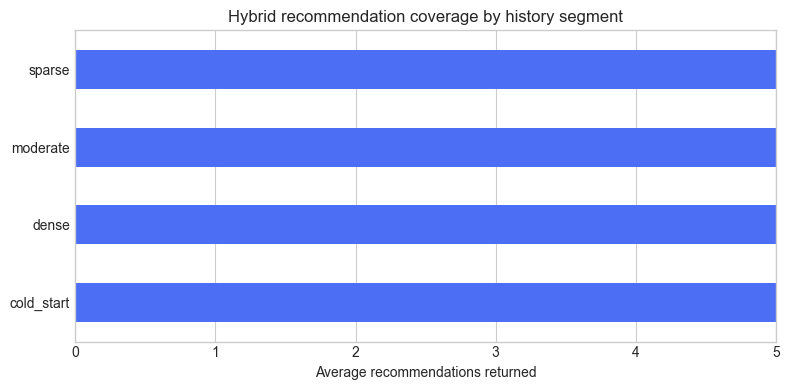

In [12]:
cohort_rows = []
for student_id in students['student_id']:
    recs, blocked = recommend_for(student_id)
    cohort_rows.append({
        'student_id': student_id,
        'history_segment': students.set_index('student_id').loc[student_id, 'history_segment'],
        'recommendations_returned': len(recs),
        'blocked_candidates': len(blocked),
        'top_score': float(recs['hybrid_score'].iloc[0]) if len(recs) else 0.0,
    })

cohort_summary = pd.DataFrame(cohort_rows)
segment_summary = cohort_summary.groupby('history_segment')[['recommendations_returned', 'blocked_candidates', 'top_score']].mean().round(2)

fig, ax = plt.subplots(figsize=(8, 4))
segment_summary['recommendations_returned'].plot(kind='barh', color='#4C6EF5', ax=ax)
ax.set_xlim(0, 5)
ax.set_xlabel('Average recommendations returned')
ax.set_ylabel('')
ax.set_title('Hybrid recommendation coverage by history segment')
plt.tight_layout()

segment_summary

## 7. Notebook takeaway

This notebook delivers the recommendation-system slice of the proposal in a way that is easy to demo:

- Behavioral recommendations for students with sufficient history
- Content-driven fallback for sparse and cold-start students
- Grade-band guardrails that block otherwise plausible titles
- Short explanations that make the ranker more legible during a presentation

The next production step would be to connect this logic to real Destiny exports, but the ranking approach here already mirrors the proposal's intended hybrid architecture.